In [36]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
import sklearn
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv("/kaggle/input/datasets/ziadhafez/mentalhealth/Combined Data.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(53043, 3)
['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [38]:
print(df.describe())

         Unnamed: 0
count  53043.000000
mean   26521.000000
std    15312.339501
min        0.000000
25%    13260.500000
50%    26521.000000
75%    39781.500000
max    53042.000000


In [39]:
df = df.drop(columns=['Unnamed: 0'])

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     53043 non-null  object
dtypes: object(2)
memory usage: 828.9+ KB


In [41]:
df = df.dropna(subset=['statement'])
df = df.dropna(subset=['status'])

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52681 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     52681 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [43]:
df.drop_duplicates(inplace=True)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51093 entries, 0 to 52840
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  51093 non-null  object
 1   status     51093 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [45]:
print(df['status'].value_counts())

status
Normal                  16040
Depression              15094
Suicidal                10644
Anxiety                  3623
Bipolar                  2501
Stress                   2296
Personality disorder      895
Name: count, dtype: int64


In [46]:
print(df['status'].value_counts(normalize=True) * 100)

status
Normal                  31.393733
Depression              29.542207
Suicidal                20.832599
Anxiety                  7.090991
Bipolar                  4.894995
Stress                   4.493766
Personality disorder     1.751708
Name: proportion, dtype: float64


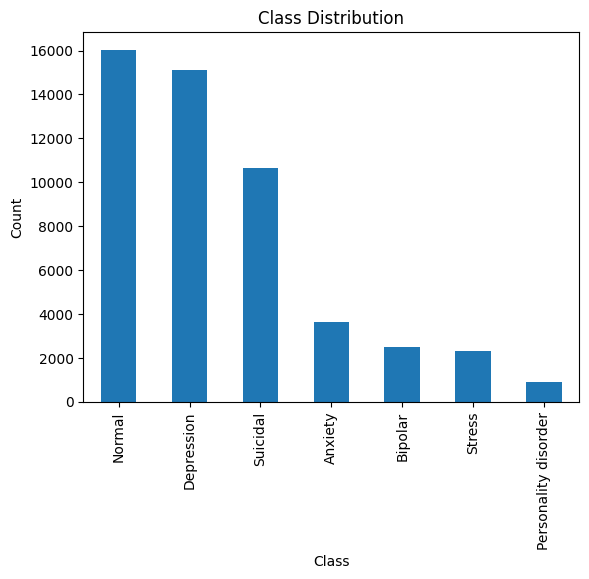

In [47]:
import matplotlib.pyplot as plt

df['status'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [48]:
#label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

In [49]:
df.head()

,statement,status
0,oh my gosh,0
1,"trouble sleeping, confused mind, restless hear...",0
2,"All wrong, back off dear, forward doubt. Stay ...",0
3,I've shifted my focus to something else but I'...,0
4,"I'm restless and restless, it's been a month n...",0


In [50]:
import string
import nltk
import re

nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [51]:
STOPWORDS = set(stopwords.words("english"))

# IMPORTANT for mental health meaning
STOPWORDS.discard("not")
STOPWORDS.discard("no")

In [52]:
punc = string.punctuation

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', punc))

In [53]:
def clean_text(text):
    # handle missing values
    text = str(text)
    
    # lowercase
    text = text.lower()
    
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # remove numbers & special characters (extra safety)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # remove stopwords
    words = text.split()
    words = [word for word in words if word not in STOPWORDS]
    
    return " ".join(words)

In [54]:
df["clean_statement"] = df["statement"].apply(clean_text)

In [55]:
print(df[["statement", "clean_statement"]].head())

                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   

                                     clean_statement  
0                                            oh gosh  
1  trouble sleeping confused mind restless heart ...  
2  wrong back dear forward doubt stay restless re...  
3  ive shifted focus something else im still worried  
4                im restless restless month boy mean  


In [56]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [57]:
def get_wordnet_pos(treebank_tag):
    """Convert treebank POS tags to WordNet POS tags"""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [58]:
def lemmatize_words(text):
    """Lemmatize with POS tagging"""
    tokens = word_tokenize(text.lower())
    pos_tags = nltk.pos_tag(tokens)
    
    lemmatized = []
    for word, pos in pos_tags:
        wordnet_pos = get_wordnet_pos(pos)
        lemma = lemmatizer.lemmatize(word, pos=wordnet_pos)
        lemmatized.append(lemma)
    
    return ' '.join(lemmatized)

In [59]:
df["clean_statement"] = df["clean_statement"].apply(lemmatize_words)

In [60]:
print(df[["statement", "clean_statement"]].head())

                                           statement  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   

                                     clean_statement  
0                                            oh gosh  
1     trouble sleep confuse mind restless heart tune  
2  wrong back dear forward doubt stay restless re...  
3      ive shift focus something else im still worry  
4                im restless restless month boy mean  


In [61]:
X = df["clean_statement"].values
y = df["status"].values

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import seaborn as sns
import matplotlib.pyplot as plt

num_classes = 7

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

In [78]:
from sklearn.utils import class_weight
from sklearn.utils.class_weight import compute_class_weight

num_classes = len(np.unique(y_train))

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: class_weights[i] for i in range(num_classes)}

#class_weights_dict[2] = class_weights_dict[2] * 1.2   # Depression - reduce from 1.5
#class_weights_dict[4] *= 1.8   # Personality disorder - reduce from 2.5
#class_weights_dict[5] *= 1.3   # Stress - reduce from 1.5
#class_weights_dict[6] *= 1.8   # Suicidal - bring back a moderate weight

print("Class weights:", class_weights)

train_counts = np.bincount(y_train)
for idx, count in enumerate(train_counts):
    print(f"Class {idx}: {count} samples")


Class weights: [2.01627861 2.94460053 0.48082533 0.45729054 8.15522745 3.1890458
 0.68414093]
Class 0: 2896 samples
Class 1: 1983 samples
Class 2: 12144 samples
Class 3: 12769 samples
Class 4: 716 samples
Class 5: 1831 samples
Class 6: 8535 samples


In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

num_classes = len(np.unique(y_train))

model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    Dropout(0.2),
    
    Bidirectional(LSTM(164, return_sequences=True)),
    Dropout(0.2),
    
    Bidirectional(LSTM(164, return_sequences=False)),
    Dropout(0.2),
    
    Dense(256, activation='relu'),
    Dropout(0.15),
    Dense(64, activation='relu'),
    
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [80]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [81]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

In [82]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/100
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.4618 - loss: 1.5354 - val_accuracy: 0.6413 - val_loss: 0.9657 - learning_rate: 0.0010
Epoch 2/100
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.6422 - loss: 1.0362 - val_accuracy: 0.6369 - val_loss: 0.8889 - learning_rate: 0.0010
Epoch 3/100
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.6859 - loss: 0.8515 - val_accuracy: 0.6772 - val_loss: 0.8216 - learning_rate: 0.0010
Epoch 4/100
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.7235 - loss: 0.6702 - val_accuracy: 0.7075 - val_loss: 0.8039 - learning_rate: 0.0010
Epoch 5/100
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/step - accuracy: 0.7546 - loss: 0.5694 - val_accuracy: 0.7135 - val_loss: 0.7651 - learning_rate: 0.0010
Epoch 6/100
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - accuracy: 0.7804 - loss: 0.4890 - val_accuracy: 0.7281 - val_loss: 0.7213 - learning_rate: 0.0010
Epoch 7/100
1022/1022 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step -

In [83]:
loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=0)

print(f"\nTest Set Results:")
print(f"  Loss: {loss:.4f}")
print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


Test Set Results:
  Loss: 0.6912
  Accuracy: 0.7341 (73.41%)


320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
                      precision    recall  f1-score   support

             Anxiety       0.79      0.82      0.80       727
             Bipolar       0.62      0.82      0.70       518
          Depression       0.83      0.48      0.61      2950
              Normal       0.92      0.87      0.90      3271
Personality disorder       0.43      0.56      0.49       179
              Stress       0.41      0.69      0.51       465
            Suicidal       0.58      0.82      0.68      2109

            accuracy                           0.73     10219
           macro avg       0.65      0.72      0.67     10219
        weighted avg       0.77      0.73      0.73     10219



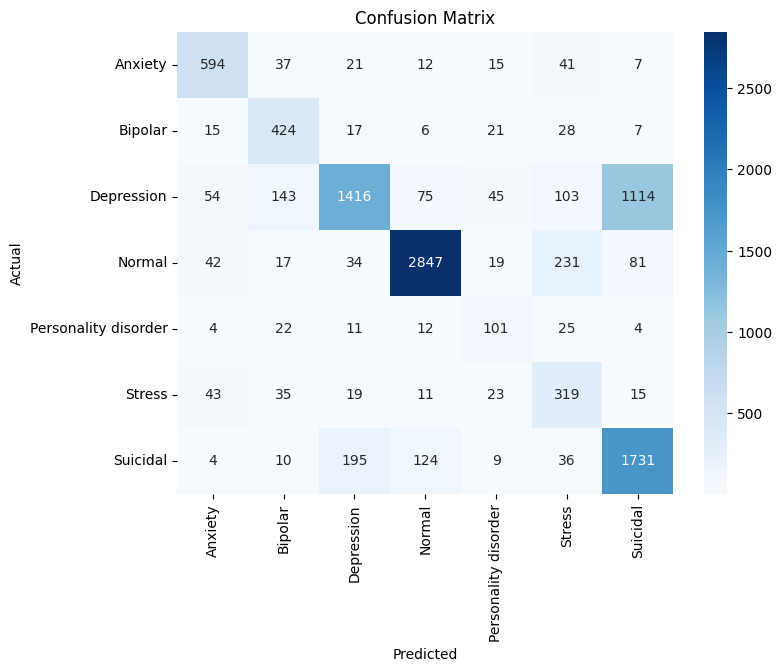

In [86]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_pred = model.predict(X_test_pad)
y_pred_proba = model.predict(X_test_pad)

# If suicidal probability is above a lower threshold, prefer suicidal
SUICIDAL_THRESHOLD = 0.4  # tune this (default argmax uses 0.5)

y_pred_classes = []
for probs in y_pred_proba:
    if probs[6] >= SUICIDAL_THRESHOLD:  # index 6 = Suicidal
        y_pred_classes.append(6)
    else:
        y_pred_classes.append(np.argmax(probs))

y_pred_classes = np.array(y_pred_classes)

# Classification report
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()